In [2]:
%%capture # Removes output
%pip install classy camb arviz numpy matplotlib cobaya getdist

UsageError: unrecognized arguments: Removes output


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# tools
import arviz as az # Library for Bayesian analysis

# Bayesian inference
import cobaya
from getdist import loadMCSamples, MCSamples
from getdist import plots as gdplot

# Theory codes
import classy
import camb


In [2]:
def import_LCDM_chains_from_npz(root):
    data = np.load(root+".npz")
    n           = int(data["n_chains"])
    param_names = data["param_names"].tolist()

    # Expand multiplicity weights so every sample counts once
    # In MCMC when we rejected new sample, we included the current state into the samples
    # The weight shows how long the current state was "stuck".
    expanded = [
        np.repeat(data[f"samples_{i}"], data[f"weights_{i}"].astype(int), axis=0)
        for i in range(n)
    ]

    # ArviZ requires equal-length chains — truncate to shortest
    min_len  = min(len(e) for e in expanded)
    expanded = [e[:min_len] for e in expanded]

    posterior = {
        p: np.stack([e[:, j] for e in expanded])   # (n_chains, n_draws)
        for j, p in enumerate(param_names)
    }
    if az.__version__[0] == "1":
        idata = az.from_dict(data = {"posterior": posterior})
    else:
        idata = az.from_dict(posterior=posterior)
    return idata

In [3]:
data = np.load("chains/LCDM.npz")
idata = import_LCDM_chains_from_npz("chains/LCDM")
N_chains = data["n_chains"].item()

# MCMC diagnostics

## Multimodality

In [4]:
def f_gaussian(x, mean, std):
    return np.exp(-0.5*(x-mean)**2/std**2)/np.sqrt(2*std**2*np.pi)

def multimodality_example(start=0, n_steps=100, separation=3, amplitude1=0.5, amplitude2=0.5):
    f_distribution = lambda x: amplitude1*f_gaussian(x, -abs(separation), 0.5) + amplitude2*f_gaussian(x, abs(separation), 0.5)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.linspace(-6, 6, 10_000)
    y = f_distribution(x)
    
    step_count = 0
    steps = [[start], [f_distribution(start)]]
    while step_count < n_steps:
        new_step = np.random.normal(steps[0][-1], 0.5)
        new_step_value = f_distribution(new_step)
        if (new_step_value > steps[1][-1]):
            steps[0].append(new_step)
            steps[1].append(new_step_value)
            step_count+=1
        else:
            p = np.random.random(1)
            if (new_step_value/steps[1][-1] > p):
                steps[0].append(new_step)
                steps[1].append(new_step_value)
                step_count+=1


    ax.plot(x, y)
    ax.plot(steps[0], steps[1], color="red", marker="o", markersize=5, markerfacecolor="green")
    ax.set_yscale("log")
    ax.set_xlabel("x")
    ax.set_ylabel("logL")

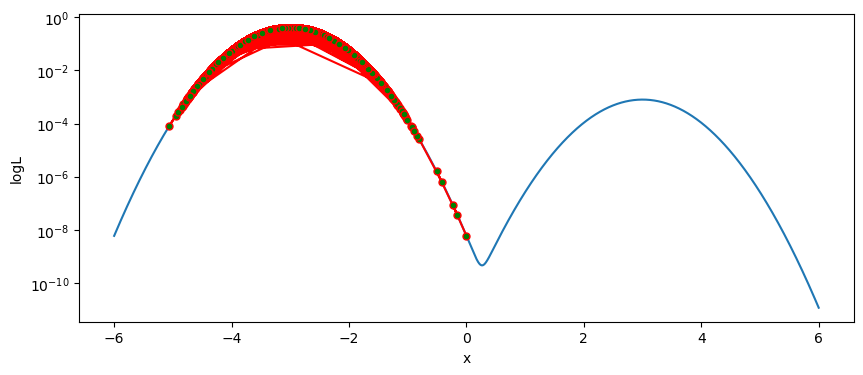

In [6]:
multimodality_example(start=0, n_steps=100_000, amplitude2=1e-3, separation=3)

Many MCMC algorithms struggle with multimodality, especially Metropolis-Hastings. The problem arises because the next step depends on the previous one and it is difficult to cross the "valley" (low probability region) between the peaks. Of course if the peaks are close enough then we can still sample correctly. So the main problem with multimodality is that the walker(s) can get stuck in one mode and fail to sample the true posterior correctly, making any subsequent analysis unreliable.

The easiest way to detect multimodality is visual. It is good practice to run multiple chains per analysis, initialized far apart from each other. If at least one chain finds a secondary peak and gets stuck there, you will see it in the trace plot. It is then worth checking the posterior value at that mode — if $\Delta \text{logL} \gtrsim 15$–$20$ it may be negligible and not affect the analysis.

There are options to mitigate multimodality, although none are guaranteed. Usually this means using different transition rules or algorithms.

### Parallel tempering

The main idea of **parallel tempering** is to run multiple chains at different **"temperatures"**. The name comes from metallurgy — heating a material allows its atoms to explore more configurations before settling. Mathematically, a chain at temperature $T$ samples from the tempered distribution

\begin{equation}
    \pi_T(\theta) \propto L(\theta)^{1/T} \, \pi(\theta)
\end{equation}

where $L(\theta)$ is the likelihood and $\pi(\theta)$ is the prior. At $T=1$ this is the true posterior. At $T > 1$ the likelihood is flattened — peaks are less pronounced and valleys are shallower — making it easier for the chain to cross between modes. At $T \to \infty$ the chain samples the prior and explores the full parameter space freely.

The $T=1$ chain periodically proposes to swap its current state with a higher-temperature chain. If the swap is accepted (following a Metropolis criterion), the cold chain can jump to a region of parameter space it could not reach by itself. True posterior samples come only from the $T=1$ chain; the hotter chains exist purely to help it escape local modes.

### Nested sampling

Nested sampling takes a completely different approach. Instead of starting near the posterior peak and exploring locally, it starts from the *entire prior* and systematically works inward. The algorithm maintains a set of $N$ **live points** drawn at random from the prior, and proceeds as follows:

1. Find the live point with the **lowest** likelihood — call it $L_\text{min}$
2. Discard it (save it for later) and replace it with a new point drawn from the prior, subject to the constraint $L > L_\text{min}$
3. Repeat — the floor $L_\text{min}$ rises at each step, progressively squeezing the live points into regions of higher and higher likelihood

The live points trace nested "shells" of increasing likelihood, like the layers of an onion being peeled from the outside in. Because every step must stay above the current likelihood floor, the points naturally explore *all* high-likelihood regions — including secondary modes that an MCMC chain starting near one peak would never find.

The evidence is the primary output: each discarded point contributes a slice of the integral $\mathcal{Z} = \int L(\theta)\,\pi(\theta)\,\mathrm{d}\theta$, and summing these slices gives $\mathcal{Z}$ directly. Posterior samples can be recovered from the discarded points, weighted by their likelihood contribution.

A frequently used implementation is [**PolyChord**](https://arxiv.org/abs/1506.00171), which is designed for high-dimensional parameter spaces and is integrated into Cobaya.

## Burn-in, chain convergence and autocorrelation

The output of the Metropolis-Hastings algorithm are the chains. At the beginning the chain values are dependent on the initial position of the chain and step by step it gets closer to the high probability region. So the initial values have not usually sampled the true posterior properly. To get rid of the bias due to the initial position it is good practice to use **burn-in**, which means discarding the first $N$ steps. Using burn-in helps to discard biased steps and get a more accurate estimate of the posterior. There is no fixed value for how many steps should be discarded, but the general approach is $10$–$30\%$ of the total steps. The main decision should be made based on diagnostic measures — the following subsections cover the main tools for this: trace plots, the Gelman-Rubin statistic, and effective sample size.

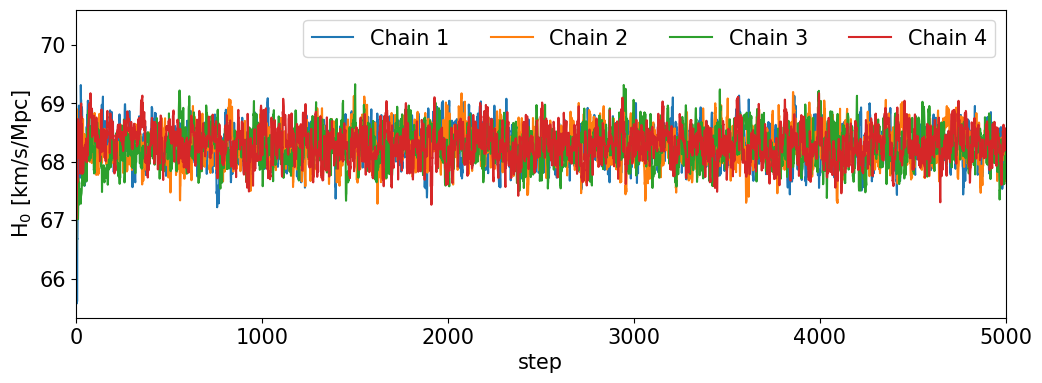

In [9]:
with plt.rc_context({"font.size": 15}):
    # All chains have around 11700 steps
    LENGTH = 5000
    plt.figure(figsize=(12, 4))
    for i in range(N_chains):
        plt.plot(data[f"samples_{i}"][:, 2], label=f"Chain {i+1}")
    plt.xlabel("step")
    plt.xlim(0, LENGTH)
    plt.legend(ncols=N_chains)
    plt.ylabel(r"$\text{H}_0$ [km/s/Mpc]")

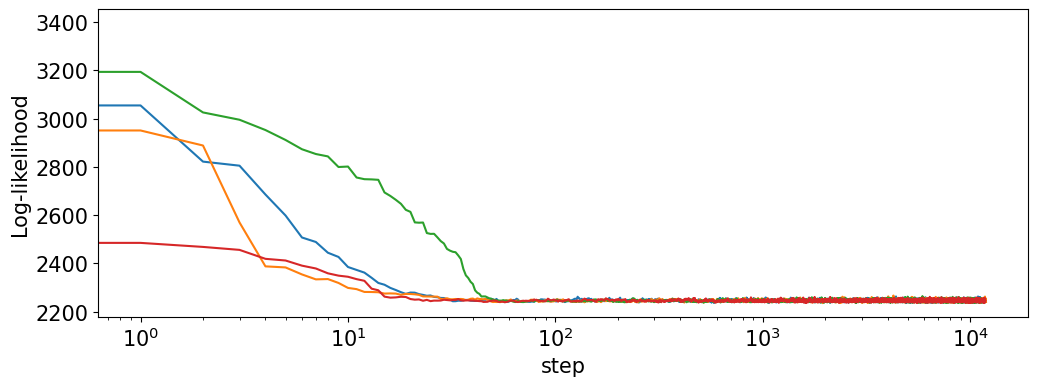

In [10]:
with plt.rc_context({"font.size": 15}):
    # All chains have around 11500 steps
    LENGTH = 11500
    plt.figure(figsize=(12, 4))
    for i in range(N_chains):
        plt.plot(data[f"loglikes_{i}"])
    plt.xlabel("step")
    # plt.xlim(0, LENGTH)
    plt.ylabel(r"Log-likelihood")
    plt.xscale("log")

In the $H_0$ trace plot above, notice how all four chains quickly settle into the same narrow band after only a small number of steps — this is a sign of fast convergence and indicates that the initial positions have little influence on the result. The first portion of those steps (the burn-in) should still be discarded. In the log-likelihood plot, all chains converge to the same plateau, confirming they are sampling the same region of parameter space. If you saw one chain stuck at a noticeably different log-likelihood level, that would suggest either a secondary mode or a chain that has not yet converged.

When the chains are sampling a stationary distribution — meaning a distribution that no longer changes as more steps are taken — we say the chain has **converged**. This ideally means the chains are sampling the true posterior, and that the initial position no longer has any effect. Visually inspecting trace plots becomes impractical with many parameters, so we also use a quantitative convergence diagnostic: the **Gelman-Rubin statistic** ($\hat{R}$).

**The intuition.** If all chains have converged to the same posterior, they should all *look alike* — they should be exploring the same region and have roughly the same spread. We can make this precise by comparing two quantities:
* $W$ — the variance **within** each chain (how spread out samples are inside a single chain)
* $B$ — the variance **between** chains (how spread out the chain *means* are relative to each other)

If the chains have converged, $B$ should be small compared to $W$ — the chain means are all in roughly the same place. If $B$ is large, the chains are sitting in different locations, which signals they have *not* converged (or that there is multimodality). The Gelman-Rubin statistic captures this by forming a ratio: if everything is consistent, the ratio should be close to 1.

**The formula.** More precisely, with $N$ samples per chain and $J$ chains total:

\begin{equation}
    \begin{split}
        & W = \frac{1}{J}\sum_{j=1}^{J}\left(\frac{1}{N-1}\sum_{i=1}^{N}(\theta_i^{j} - \overline{\theta}_j)^2 \right)\,, \quad
          B = \frac{N}{J-1}\sum_{j=1}^{J} (\overline{\theta}_j - \overline{\theta}_*)^2
    \end{split}
\end{equation}

where $\overline{\theta}_j$ is the mean of chain $j$ and $\overline{\theta}_*$ is the grand mean across all chains. Then

\begin{equation}
    \hat{R} = \frac{\frac{N-1}{N}W + \frac{1}{N}B}{W}
\end{equation}

As $N \to \infty$, well-converged chains give $B \to 0$ and $\hat{R} \to 1$. In practice, the condition $\hat{R} - 1 \leq 0.01$ is taken as a sign of convergence.

In [14]:
# Let's use arviz to calculate Rhat
# Change range of data to see how Rhat changes
START = 0
END = None # All the samples to the end
az.rhat(idata.sel(draw=slice(START, END))) 

<xarray.Dataset> Size: 112B
Dimensions:                              ()
Data variables: (12/14)
    logA                                 float64 8B 1.003
    n_s                                  float64 8B 1.002
    H0                                   float64 8B 1.006
    omega_b                              float64 8B 1.003
    omega_cdm                            float64 8B 1.007
    tau_reio                             float64 8B 1.003
    ...                                   ...
    chi2__sn.desdovekie                  float64 8B 1.007
    chi2__bao.desi_dr2                   float64 8B 1.006
    chi2__planck_2018_lowl.TT            float64 8B 1.002
    chi2__planck_2018_lowl.EE            float64 8B 1.001
    chi2__planck_2018_highl_plik.TTTEEE  float64 8B 1.001
    chi2__planck_2018_lensing.clik       float64 8B 1.001

A less common but sometimes useful statistic is the **effective sample size (ESS)**. To calculate it we first need the **autocorrelation**, which quantifies how dependent consecutive samples are on each other. Autocorrelation is defined as

\begin{equation}
    \rho_\tau = \frac{c_\theta(\tau)}{c_\theta(0)}\,, \text{ where } c_\theta(\tau) = \frac{1}{N-\tau}\sum_{n=1}^{N-\tau}(\theta_n-\overline{\theta})(\theta_{n+\tau}-\overline{\theta}) 
\end{equation}

Here $\tau$ is the lag — how many steps apart two samples are. $\rho_0 = 1$ by definition, and we expect $\rho_\tau \to 0$ as $\tau$ grows. The plots below show the autocorrelation for each parameter in our $\Lambda$CDM chains.

In [15]:
# Autocorrelation plot
if az.__version__[0]=="1":
    az.style.use("arviz-variat")
    az.plot_autocorr(idata, var_names=["logA"])
    az.plot_autocorr(idata, var_names=["n_s"])
    az.plot_autocorr(idata, var_names=["H0"])
    az.plot_autocorr(idata, var_names=["omega_b"])
    az.plot_autocorr(idata, var_names=["omega_cdm"])
    az.plot_autocorr(idata, var_names=["tau_reio"])


Now coming back to ESS. Without going into too much detail, the ESS simply estimates how many independent samples we have. As the samples are usually correlated to each other (quantified by the autocorrelation) the "real" sample size is always smaller. The definition for ESS is the following
\begin{equation}
    \text{ESS} = \frac{N}{1 + 2 \sum_{k=1}^{\infty}\rho_k}\,.
\end{equation}
The effective sample size gives a precision estimate for the posterior
\begin{equation}
    \text{Var}(\hat{\theta}) \approx \frac{\sigma^2}{\text{ESS}}
\end{equation}

where $\hat{\theta}$ is some estimate of a parameter (for example the mean of $\theta$) and $\sigma^2$ is the posterior variance.

> **Practical note.** As a rough rule of thumb, ESS $\gtrsim 200$–$300$ per parameter is generally sufficient for reliable posterior estimates (means, credible intervals). For tail quantities such as 95% or 99% upper limits, a larger ESS is needed. In the LCDM chains above, arviz reports ESS $\sim 1000$–$2000$ per parameter, which is healthy. If your ESS is very low — say below 100 — consider running the chains longer or thinning less aggressively.

In [16]:
# Effective sample size
az.ess(idata)

<xarray.Dataset> Size: 112B
Dimensions:                              ()
Data variables: (12/14)
    logA                                 float64 8B 1.827e+03
    n_s                                  float64 8B 2.057e+03
    H0                                   float64 8B 1.982e+03
    omega_b                              float64 8B 1.718e+03
    omega_cdm                            float64 8B 1.36e+03
    tau_reio                             float64 8B 1.71e+03
    ...                                   ...
    chi2__sn.desdovekie                  float64 8B 1.724e+03
    chi2__bao.desi_dr2                   float64 8B 1.877e+03
    chi2__planck_2018_lowl.TT            float64 8B 1.659e+03
    chi2__planck_2018_lowl.EE            float64 8B 2.26e+03
    chi2__planck_2018_highl_plik.TTTEEE  float64 8B 2.424e+03
    chi2__planck_2018_lensing.clik       float64 8B 2.108e+03

## Model comparison

### Bayes factor

One way to compare models is to use the Bayes factor, which we mentioned in the first lecture. Recall that the evidence $P(D|M)$ is the likelihood integrated over all parameter values — it measures how well a model predicts the data on average, not just at the best-fit point. The Bayes factor is the ratio of evidences between two models:

\begin{equation}
    \text{BF}_{12} = \frac{P(D|M_1)}{P(D|M_2)} 
\end{equation}

We typically want $\text{BF}_{12} \gtrsim 4$ to claim some preference for one model. Note that computing the evidence directly requires integrating over the full parameter space, which is expensive — this is one reason nested sampling is useful.

### Maximum likelihood methods

#### Akaike Information Criterion (AIC)

AIC is an estimator of prediction error. It has two components: how good the fit is and how overfitted the model is. A lower AIC means a better model. By definition

\begin{equation}
    \text{AIC} = 2k - 2 \log(\hat{L})
\end{equation}
where $\hat{L}$ is the maximum value of the likelihood and $k$ is the number of free parameters. The more free parameters a model has, the higher the AIC penalty — for example, a model with 6 parameters is penalized by $2 \times 6 = 12$ versus $2 \times 3 = 6$ for a 3-parameter model, regardless of fit quality. The lower the log-likelihood value, the better the fit and the lower the AIC.

To get a more quantitative comparison between models, let's say we have multiple models with different AIC values. $\text{AIC}_*$ is the lowest of them. Then the value
\begin{equation}
    \exp\left(\frac{\text{AIC}_* - \text{AIC}_n}{2}\right)
\end{equation}

gives an estimate of how likely the $n$-th model minimizes the information loss compared to the $\text{AIC}_*$ model.

It is important that the AIC value itself does not give any information. It is only informative when comparing against other models using the same dataset.

### Bayesian Information Criterion (BIC)

BIC is related to the AIC. Again, this value is penalized by having more free parameters but gets a smaller value when the log-likelihood is smaller.

BIC tries to estimate the evidence, thus making it possible to obtain estimates for the Bayes factor. BIC is defined as 
\begin{equation}
    \text{BIC} = k \log(n) - 2 \log(\hat{L})
\end{equation}

where $k$ is again the number of free parameters and $n$ is the number of data points. BIC is greater than AIC if $n>7$. Like AIC, a smaller value for BIC means a better model. Also, the BIC value itself does not say how good a model is — we need to compare different BIC values to each other: $\Delta\text{BIC} = \text{BIC}_2 - \text{BIC}_1 \approx -2 \log(\text{BF}_{12})$.

> **Note on CMB analyses.** The definition of $n$ can be ambiguous sometimes, Especially if the data is correlated. For this reason BIC is rarely used directly in CMB cosmology, and computing the full Bayesian evidence via nested sampling is preferred.

# Tools

## Cobaya

[Cobaya](https://cobaya.readthedocs.io/en/latest/) is a Python-based cosmological inference framework, created by Jesus Torrado and Anthony Lewis, that ties together likelihoods, theory codes, and samplers into a single pipeline. Without a tool like Cobaya, you would have to manually call CLASS or CAMB, evaluate each likelihood, and implement the sampler yourself — Cobaya handles all of this from a single config file.

It provides built-in access to the most commonly used datasets in cosmology:
 * CMB likelihoods (Planck, BICEP/Keck)
 * Type Ia supernovae likelihoods
 * BAO measurements (DESI)

It interfaces directly with the theory codes CAMB and CLASS to compute the CMB power spectra needed by these likelihoods, and supports two samplers out of the box:
 * Modified Metropolis-Hastings
 * Polychord (nested sampler)

To run an analysis you write a config file in YAML format specifying:
 * Which likelihoods to use and their settings
 * Priors for each parameter
 * Which parameters are fixed, sampled, or derived
 * Which sampler to use and its settings
 * Which theory code to use and its settings

Once the config is ready, a single call to `cobaya.run()` launches the analysis and writes the chains to disk. These can then be loaded and visualised with **GetDist**, as shown in the code below.

It is also possible to define custom likelihoods or add new samplers, making Cobaya flexible enough to accommodate non-standard models.

In [ ]:
## Install Supernova and BAO data (Can be ignore if done)
from cobaya.install import install
install("sn.desdovekie", "bao.desi_dr2.desi_bao_all", path="./data")

In [ ]:
# Estimated runtime ~20 min
cobaya_config = cobaya.yaml.yaml_load("examples/example.yaml")
updated_config, sampler = cobaya.run(cobaya_config)

**GetDist** is a Python library for analysing and visualising MCMC chains. It can load chains written by Cobaya directly and produces the standard cosmology plots — 1D marginal distributions and 2D contour plots (triangle/corner plots). The triangle plot below shows the marginalised posterior for $\Omega_m$. In a full analysis this would show all sampled parameters and their correlations, which is useful for spotting degeneracies.

In [17]:
samples = loadMCSamples("resume/cobaya")
samples.removeBurn(0.3) # Remove the burn-in

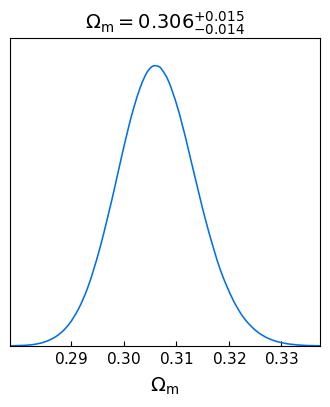

In [18]:
# Create the posterior plot
g = gdplot.get_subplot_plotter(subplot_size=4)
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4
g.settings.title_limit_fontsize = 14

g.triangle_plot(
    samples,
    ["Omega_m"],
    title_limit=2,
    filled=True,
)
plt.show()

## CLASS

[CLASS](http://class-code.net/) (the Cosmic Linear Anisotropy Solving System) is a code written in C/C++ that solves the Boltzmann equations to simulate the evolution of linear perturbations in the universe and compute cosmological observables. While Cobaya calls CLASS internally during an MCMC run, you would use CLASS directly when you want to quickly compute a single spectrum, explore how an observable depends on a parameter, or prototype a new likelihood.

CLASS covers all standard cosmological models out of the box. It is controlled by passing a dictionary of cosmological parameters (e.g. $H_0$, $\Omega_b h^2$, $\Omega_c h^2$, $n_s$, $A_s$, $\tau_\text{reio}$) along with output flags that specify what to compute — for example `tCl` for the CMB temperature power spectrum, `mPk` for the matter power spectrum, or `lCl` for the lensing potential. It has a Python wrapper called **classy** which provides a convenient interface without needing to write any C code. The examples below show how to set up a CLASS run and extract the most commonly used outputs.

In some cases it is necessary to modify the CLASS source code directly — for example to implement a new dark energy model or a non-standard perturbation equation — and then reinstall classy from the modified source.

### Horndeski and hi_class

If you are interested in scalar-tensor theories of gravity, CLASS has a modification called [``hi_class``](https://miguelzuma.github.io/hi_class_public/) (Zumalacárregui et al. 2017). Standard CLASS assumes GR; hi_class modifies the background and perturbation equations to account for an extra scalar degree of freedom $\phi$, which changes the predicted CMB spectrum and matter power spectrum — precisely the observables we use to test gravity.

**The action.** hi_class implements the full Horndeski action, the most general scalar-tensor theory with second-order equations of motion:

\begin{equation}
    S[g_{\mu\nu},\phi]=\int\mathrm{d}^{4}x\,\sqrt{-g}\left[\sum_{i=2}^{5}\frac{\mathcal{L}_{i}}{8\pi G_\mathrm{N}}+\mathcal{L}_{\mathrm{m}}[g_{\mu\nu},\psi_{M}]\right]
\end{equation}

with

\begin{align}
    \mathcal{L}_{2} &= G_{2}(\phi, X) \\
    \mathcal{L}_{3} &= -G_{3}(\phi, X)\Box\phi \\
    \mathcal{L}_{4} &= G_{4}(\phi, X)R + G_{4X}\left[(\Box\phi)^{2}-\phi_{;\mu\nu}\phi^{;\mu\nu}\right] \\
    \mathcal{L}_{5} &= G_{5}(\phi, X)G_{\mu\nu}\phi^{;\mu\nu} - \frac{G_{5X}}{6}\left[(\Box\phi)^{3}+2{\phi_{;\mu}}^{\nu}{\phi_{;\nu}}^{\alpha}{\phi_{;\alpha}}^{\mu}-3\phi_{;\mu\nu}\phi^{;\mu\nu}\Box\phi\right]
\end{align}

where $2X \equiv -\partial_\mu\phi\,\partial^\mu\phi$ is the kinetic term and $G_{iX} \equiv \partial G_i/\partial X$. GR is recovered when $G_4 = 1/2$ and all other $G_i = 0$.

hi_class is a separate fork of CLASS and must be installed independently, but it uses the same classy Python interface, so the learning curve is minimal. A more recent fork, [``mochi_class``](https://github.com/mcataneo/mochi_class_public), extends hi_class, improves numerical stability near the braiding instability, and is generally the better choice for new work.

For hi_class to add new model, the user has to modify the source code. This is done through just introducing the new Lagrangian.

## CAMB

[CAMB](https://camb.info/) (Code for Anisotropies in the Microwave Background) is a Boltzmann solver similar in scope to CLASS, written in Fortran with a Python interface via the `camb` package. It computes the same observables — CMB power spectra, matter power spectrum, angular diameter distance — but with a different numerical approach and a different Python API, as shown in the code below. CAMB is the older of the two codes and is the default theory code used by several Planck likelihoods, so you are likely to encounter it when working with official Planck data products. CLASS and CAMB agree at the sub-percent level for standard $\Lambda$CDM, as the comparison plots below demonstrate.

The main practical difference from classy is the API: rather than passing a settings dictionary, CAMB uses a `CAMBparams` object where cosmological parameters, initial power spectrum settings, and output options are set through dedicated methods before calling `camb.get_results()`.

### EFTCAMB

[EFTCAMB](http://eftcamb.org/) is a modified version of CAMB that implements the **Effective Field Theory** approach, a model-independent framework for describing perturbations in the presence of a single extra scalar degree of freedom. EFTCAMB does not require specifying a Lagrangian directly

A key advantage of EFTCAMB over hi_class is that it can handle **$f(R)$ gravity** natively.
<figure style="text-align: center;">
  <img src="images/TheoryCodes.png" alt="Comparison between theory codes" style="width: 90%; height: auto;">
  <figcaption>Capabilities of different theory codes. Figure from Bellini, E., Barriera, A., Frusciante, N. et al, "A comparison of Einstein-Boltzmann solvers for testing General Relativity" <a>https://arxiv.org/pdf/1709.09135</a>. The key takeaway is that no single code covers all theories — CLASS/hi_class can be the choice for Horndeski theories, while EFTCAMB is preferred for f(R) and EFT-based models.</figcaption>
</figure>

## Comparison

The following cells compare CLASS and CAMB for three key observables, all computed using Planck 2018 best-fit $\Lambda$CDM parameters. Since both codes solve the same underlying Boltzmann equations, they should agree closely — any differences reflect numerical implementation choices rather than physics. Each comparison is shown as both an overlay plot and a residual panel to make the level of agreement concrete.

In [19]:
settings_for_CLASS = {
    # Values from Planck 2018 best-fit for base LCDM_CLASS
    "h": 0.6732,
    "omega_b": 0.022383,
    "omega_cdm": 0.12011,
    "tau_reio": 0.0543,
    "A_s": 2.1005829616811546e-09,
    "n_s": 0.96605,
    # Output and precision parameters
    # tCl->Temperature power spectra, pCl->Polarization power spectra
    # lCl->Lensing potential power spectra, mPk->Matter power spectra
    'output':'tCl,pCl,lCl,mPk', 
    'lensing':'yes',
    'l_max_scalars':5000,
    'z_max_pk': 100,
    # 'non linear': 'halofit',
    'P_k_max_h/Mpc': 200.0,
}
# Everything is measured in units of Mpc
LCDM_CLASS = classy.Class()
LCDM_CLASS.set(settings_for_CLASS)
LCDM_CLASS.compute()

In [20]:
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.32, ombh2=0.022383, omch2=0.12011)
pars.InitPower.set_params(ns=0.96605, As=2.1005829616811546e-09)
pars.Reion.set_tau(0.0543)
pars.set_for_lmax(5000)
# Compute matter power spectrum at multiple redshifts
# Note: CAMB stores results with highest redshift first
pars.set_matter_power(redshifts=[0, 0.5, 1.0], kmax=100)
LCDM_CAMB = camb.get_results(pars)

Note: redshifts have been re-sorted (earliest first)


### Matter power spectrum

The matter power spectrum $P(k)$ describes the amplitude of density fluctuations as a function of scale. Key features to notice: the broad peak around $k \sim 0.01\ \mathrm{Mpc}^{-1}$ corresponds to the scale that entered the horizon at matter-radiation equality; the wiggles at smaller scales are the BAO signal; and the steep fall-off at large $k$ reflects Silk damping. Showing the spectrum at multiple redshifts illustrates how structure grows over time — $P(k)$ at higher $z$ has lower amplitude at all scales.

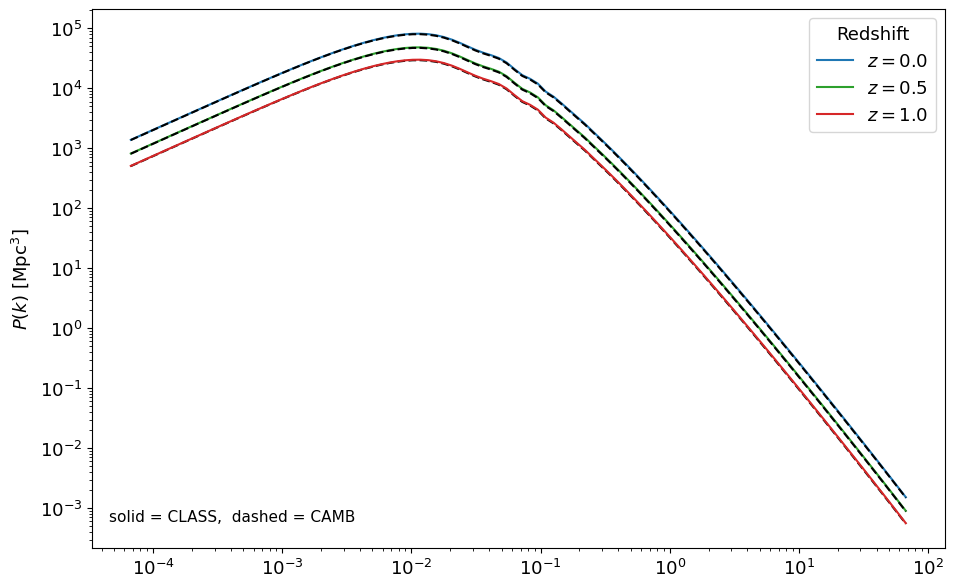

In [21]:
with plt.rc_context({"font.size": 13}):
    fig, ax = plt.subplots(figsize=(11, 7))

    redshifts = [0.0, 0.5, 1.0]
    colors = ["C0", "C2", "C3"]

    # CLASS variables: [k] = 1/Mpc, [P(k)] = Mpc^3
    # CAMB variables:  [k] = h/Mpc, [P(k)] = (Mpc/h)^3 → convert by dividing P by h^3
    h = 0.6732
    _mPk_CAMB_all = LCDM_CAMB.get_matter_power_spectrum(1e-4, 100)
    k_values = _mPk_CAMB_all[0] * h  # h/Mpc → 1/Mpc

    for z, color, camb_idx in zip(redshifts, colors, [-1, -2, -3]):
        # CAMB stores redshifts highest-first, so z=0→last, z=0.5→second-to-last, z=1→third-to-last
        _mPk_CLASS = np.array([LCDM_CLASS.pk(k=k, z=z) for k in k_values])
        _mPk_CAMB  = _mPk_CAMB_all[2][camb_idx] / h**3

        ax.plot(k_values, _mPk_CLASS, color=color, label=f"$z = {z}$")
        ax.plot(k_values, _mPk_CAMB,  color="k", linestyle="--")
    
    
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_ylabel(r"$P(k)\ [\mathrm{Mpc}^3]$")
    ax.legend(title="Redshift")
    ax.text(0.02, 0.05, "solid = CLASS,  dashed = CAMB", transform=ax.transAxes, fontsize=11,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7))

    plt.show()

The two codes agree to well within 1% across all scales and redshifts — the residuals in the lower panel confirm this. Any differences arise from numerical integration choices, not from physical disagreement, and are far below current observational uncertainties.

The plots above show the **linear** matter power spectrum. At small scales ($k \gtrsim 0.1\ \mathrm{Mpc}^{-1}$) non-linear gravitational clustering becomes important and the linear prediction breaks down. Both codes support the **halofit** prescription (non-linear effects) to account for this.

### Angular diameter distance

The angular diameter distance $D_A(z)$ is a key quantity linking observed angular sizes to physical scales — it enters directly into the calculation of CMB peak positions and BAO measurements. Unlike the luminosity distance, $D_A$ is not monotonically increasing: it peaks and then decreases at high redshift because the universe was much smaller in the past.

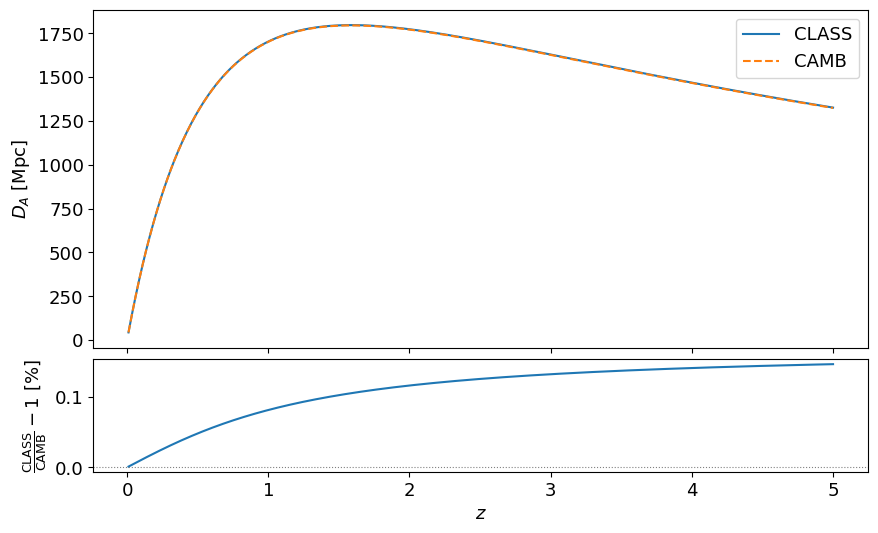

In [22]:
with plt.rc_context({"font.size": 13}):
    z_values = np.linspace(0.01, 5, 1001)

    DA_CLASS = LCDM_CLASS.angular_distance(z_values)
    DA_CAMB  = LCDM_CAMB.angular_diameter_distance(z_values)

    fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                      gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

    ax.plot(z_values, DA_CLASS, label="CLASS")
    ax.plot(z_values, DA_CAMB,  linestyle="--", label="CAMB")
    ax.set_ylabel(r"$D_A\ [\mathrm{Mpc}]$")
    ax.legend()

    ax_res.plot(z_values, (DA_CLASS / DA_CAMB - 1) * 100, color="C0")
    ax_res.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax_res.set_xlabel("$z$")
    ax_res.set_ylabel(r"$\frac{\mathrm{CLASS}}{\mathrm{CAMB}} - 1\ [\%]$")
    plt.show()

Again the two codes agree closely. The angular diameter distance peaks around $z \sim 1.6$ in $\Lambda$CDM — beyond that redshift, the expansion of the universe means sources appear smaller even though they are receding, which is the characteristic behaviour of this distance measure.

### Angular power spectra of CMB

The CMB temperature (TT) and polarisation (EE, TE) power spectra are the primary observables used to constrain cosmological parameters. The TT spectrum is dominated by acoustic oscillations; EE is the polarisation auto-spectrum sourced by the same oscillations; TE is the temperature-polarisation cross-spectrum, which can be negative in some $\ell$ ranges. All three are shown below for both CLASS and CAMB.

In [23]:
def plot_class_cl(ax, data, key):
    l = data["ell"]
    constant=l*(l+1)/(2*np.pi)
    ax.plot(l, data[key]*constant, label="CLASS")

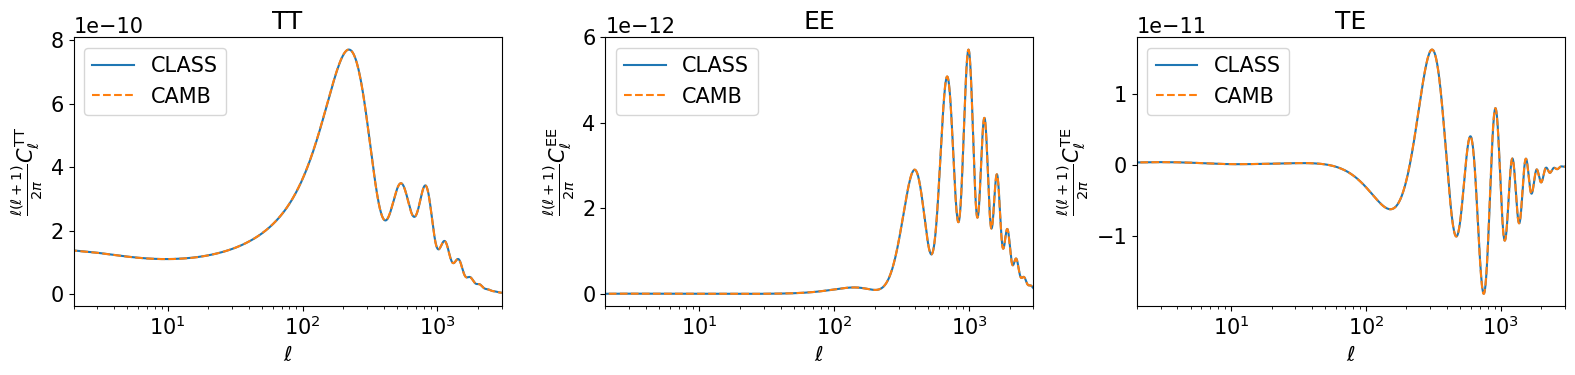

In [24]:
with plt.rc_context({"font.size": 15}):
    # CAMB column order: TT=0, EE=1, BB=2, TE=3
    spectra = [("TT", "tt", 0), ("EE", "ee", 1), ("TE", "te", 3)]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    camb_cls  = LCDM_CAMB.get_cmb_power_spectra(pars)["total"]
    class_cls = LCDM_CLASS.lensed_cl()

    l_class  = class_cls["ell"]
    l_camb   = np.arange(camb_cls.shape[0])
    fac_class = l_class * (l_class + 1) / (2 * np.pi)
    fac_camb = 1
    
    for ax, (name, class_key, camb_idx) in zip(axes, spectra):
        ax.plot(l_class, class_cls[class_key] * fac_class, label="CLASS")
        ax.plot(l_camb,  camb_cls[:, camb_idx] * fac_camb, linestyle="--", label="CAMB")
        ax.set_xscale("log")
        ax.set_xlim(2, 3000)
        ax.set_xlabel(r"$\ell$")
        ax.set_ylabel(r"$\frac{\ell(\ell+1)}{2\pi}C_\ell^{\rm " + name + r"}$")
        ax.set_title(name)
        ax.legend()

    plt.tight_layout()
    plt.show()

All three spectra agree closely between CLASS and CAMB. In TT, the acoustic peaks are clearly visible with the first peak at $\ell \approx 220$. In EE, the peaks are offset from TT — they occur at the troughs of TT because polarisation is generated by the velocity of the photon-baryon fluid rather than its density. The TE cross-spectrum oscillates between positive and negative values, which is expected: regions of high density (TT peak) tend to have low velocity (TE trough) and vice versa.